# BANK LOAN ANALYSIS REPORT

### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import piplite
await piplite.install("pandas")
await piplite.install("openpyxl")

In [6]:
import pandas as pd

df = pd.read_excel("financial_loan.xlsx")
df.head() 

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [7]:
df.tail()


,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


### Metadata of data

In [10]:
print("No of Rows:", df. shape[0])



No of Rows: 38576


In [12]:
print("No of Columns:"
, df.shape[1])


No of Columns: 24


In [13]:
df. info()


<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  str           
 2   application_type       38576 non-null  str           
 3   emp_length             38576 non-null  str           
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  str           
 6   home_ownership         38576 non-null  str           
 7   issue_date             38576 non-null  datetime64[us]
 8   last_credit_pull_date  38576 non-null  datetime64[us]
 9   last_payment_date      38576 non-null  datetime64[us]
 10  loan_status            38576 non-null  str           
 11  next_payment_date      38576 non-null  datetime64[us]
 12  member_id              38576 non-null  int64         
 13  purpose     

### Data Types

In [14]:
df.dtypes

id                                int64
address_state                       str
application_type                    str
emp_length                          str
emp_title                        object
grade                               str
home_ownership                      str
issue_date               datetime64[us]
last_credit_pull_date    datetime64[us]
last_payment_date        datetime64[us]
loan_status                         str
next_payment_date        datetime64[us]
member_id                         int64
purpose                             str
sub_grade                           str
term                                str
verification_status                 str
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [19]:
df.describe()


,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007,2021-06-08 13:36:34.193280,2021-06-26 09:52:08.909166,2021-07-26 20:42:20.605557,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


### Total Loan Application

In [20]:
total_loan_application = df['id'].count()
print("Total Loan Applications:", total_loan_application)

Total Loan Applications: 38576


### MTD Total Loan Applications


In [22]:
# Make sure issue_date is a date
df['issue_date'] = pd.to_datetime(df['issue_date'])

# Latest date in the dataset
latest_issue_date = df['issue_date'].max()

latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

# Filter to the latest month
mtd_data = df[
    (df['issue_date'].dt.year == latest_year) &
    (df['issue_date'].dt.month == latest_month)
]

# Count MTD loan applications
mtd_loan_applications = mtd_data['id'].count()

print(
    f"MTD Loan Applications for "
    f"{latest_issue_date.strftime('%B %Y')}: "
    f"{mtd_loan_applications}"
)

MTD Loan Applications for December 2021: 4314


### Total Funded Amount

In [24]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount / 1_000_000

print(f"Total Funded Amount: ${total_funded_amount_millions:.2f}M")

Total Funded Amount: $435.76M


### MTD - Total Funded Amount

In [26]:
# MTD - Total Funded Amount

df['issue_date'] = pd.to_datetime(df['issue_date'])

latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[
    (df['issue_date'].dt.year == latest_year) &
    (df['issue_date'].dt.month == latest_month)
]

mtd_total_funded_amount = mtd_data['loan_amount'].sum()
mtd_total_funded_amount_millions = mtd_total_funded_amount / 1_000_000

print(
    f"MTD Total Funded Amount for "
    f"{latest_issue_date.strftime('%B %Y')}: "
    f"${mtd_total_funded_amount_millions:.2f}M"
)

MTD Total Funded Amount for December 2021: $53.98M


### MTD Total Amount Received

In [28]:
# MTD Total Amount Received

df['issue_date'] = pd.to_datetime(df['issue_date'])

latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[
    (df['issue_date'].dt.year == latest_year) &
    (df['issue_date'].dt.month == latest_month)
]

mtd_total_amount_received = mtd_data['total_payment'].sum()
mtd_total_amount_received_millions = mtd_total_amount_received / 1_000_000

print(
    f"MTD Total Amount Received for "
    f"{latest_issue_date.strftime('%B %Y')}: "
    f"${mtd_total_amount_received_millions:.2f}M"
)

MTD Total Amount Received for December 2021: $58.07M


### Average Interest rate

In [29]:
average_interest_rate= df[ 'int_rate'].mean ()*100
print("Avg Int Rate: {:.2f}%". format(average_interest_rate))

Avg Int Rate: 12.05%


### Average Debt-to-Income Ratio (DTI)

In [30]:
average_dti= df['dti'].mean ()*100
print("Avg DTI: {:.2f}%". format(average_dti))

Avg DTI: 13.33%


### Good Loan Metrics

In [32]:
# Good Loan Metrics

good_loans = df[df['loan_status'].isin(['Fully Paid', 'Current'])]

total_loan_applications = df['id'].count()
good_loan_applications = good_loans['id'].count()

good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount / 1_000_000
good_loan_received_millions = good_loan_received / 1_000_000

good_loan_percentage = (
    good_loan_applications / total_loan_applications
) * 100

print("Good Loan Applications:", good_loan_applications)
print(f"Good Loan Funded Amount: ${good_loan_funded_amount_millions:.2f}M")
print(f"Good Loan Total Received: ${good_loan_received_millions:.2f}M")
print(f"Percentage of Good Loan Applications: {good_loan_percentage:.2f}%")

Good Loan Applications: 33243
Good Loan Funded Amount: $370.22M
Good Loan Total Received: $435.79M
Percentage of Good Loan Applications: 86.18%


### Bad Loan Metrics

In [34]:
# Bad Loan Metrics

bad_loans = df[df['loan_status'].isin(['Charged Off'])]

total_loan_applications = df['id'].count()
bad_loan_applications = bad_loans['id'].count()

bad_loan_funded_amount = bad_loans['loan_amount'].sum()
bad_loan_received = bad_loans['total_payment'].sum()

bad_loan_funded_amount_millions = bad_loan_funded_amount / 1_000_000
bad_loan_received_millions = bad_loan_received / 1_000_000

bad_loan_percentage = (
    bad_loan_applications / total_loan_applications
) * 100

print("Bad Loan Applications:", bad_loan_applications)
print(f"Bad Loan Funded Amount: ${bad_loan_funded_amount_millions:.2f}M")
print(f"Bad Loan Total Received: ${bad_loan_received_millions:.2f}M")
print(f"Percentage of Bad Loan Applications: {bad_loan_percentage:.2f}%")

Bad Loan Applications: 5333
Bad Loan Funded Amount: $65.53M
Bad Loan Total Received: $37.28M
Percentage of Bad Loan Applications: 13.82%


### Monthly Trends by Issue Date for Total Funded Amount

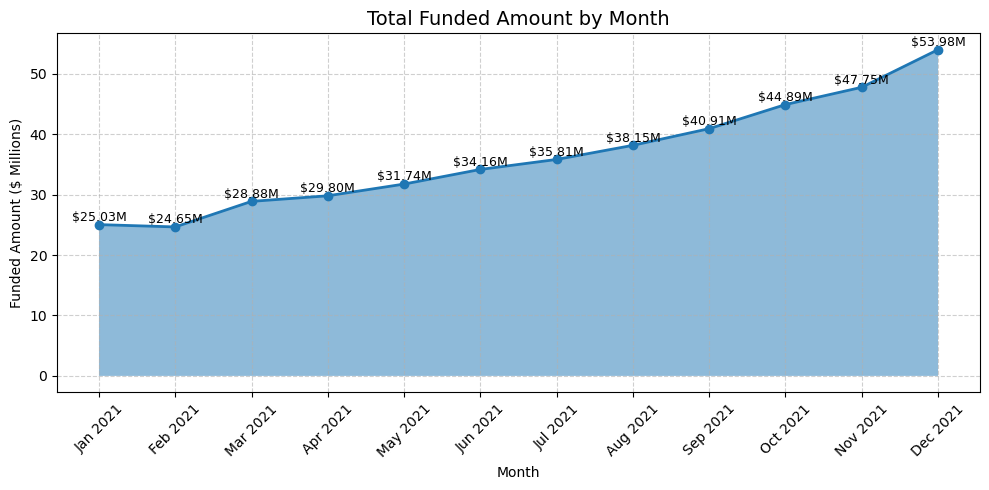

In [35]:
# Monthly Trends by Issue Date for Total Funded Amount

monthly_funded = (
    df.sort_values('issue_date')
      .assign(
          month_name=lambda x: x['issue_date'].dt.strftime('%b %Y')
      )
      .groupby('month_name', sort=False)['loan_amount']
      .sum()
      .div(1_000_000)
      .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10, 5))

plt.fill_between(
    range(len(monthly_funded)),
    monthly_funded['loan_amount_millions'],
    alpha=0.5
)

plt.plot(
    range(len(monthly_funded)),
    monthly_funded['loan_amount_millions'],
    linewidth=2,
    marker='o'
)

for i, row in monthly_funded.iterrows():
    plt.text(
        i,
        row['loan_amount_millions'] + 0.1,
        f"${row['loan_amount_millions']:.2f}M",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount ($ Millions)')

plt.xticks(
    ticks=range(len(monthly_funded)),
    labels=monthly_funded['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trends by Issue Date for Total Amount Received

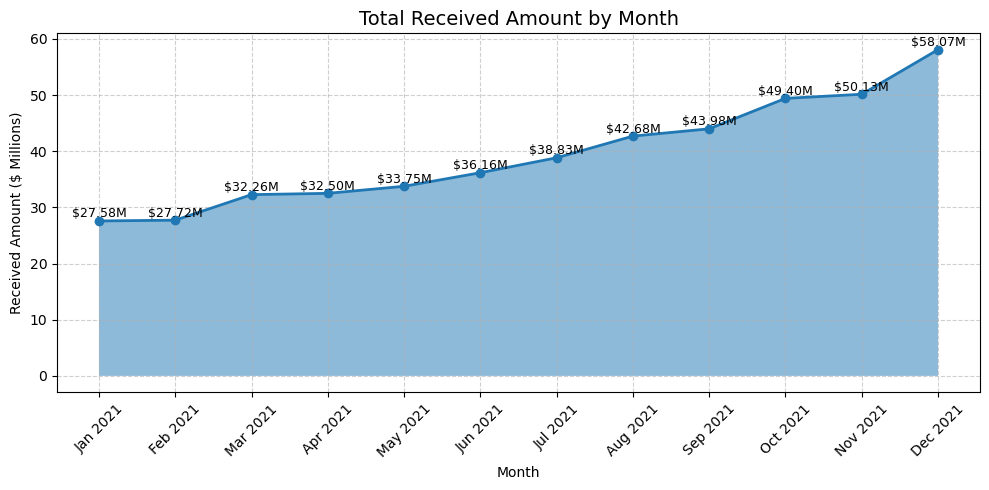

In [36]:
# Monthly Trends by Issue Date for Total Amount Received

monthly_received = (
    df.sort_values('issue_date')
      .assign(
          month_name=lambda x: x['issue_date'].dt.strftime('%b %Y')
      )
      .groupby('month_name', sort=False)['total_payment']
      .sum()
      .div(1_000_000)
      .reset_index(name='received_amount_millions')
)

plt.figure(figsize=(10, 5))

plt.fill_between(
    range(len(monthly_received)),
    monthly_received['received_amount_millions'],
    alpha=0.5
)

plt.plot(
    range(len(monthly_received)),
    monthly_received['received_amount_millions'],
    linewidth=2,
    marker='o'
)

for i, row in monthly_received.iterrows():
    plt.text(
        i,
        row['received_amount_millions'] + 0.1,
        f"${row['received_amount_millions']:.2f}M",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Total Received Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount ($ Millions)')

plt.xticks(
    ticks=range(len(monthly_received)),
    labels=monthly_received['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trends by Issue Date for Total Loan applications

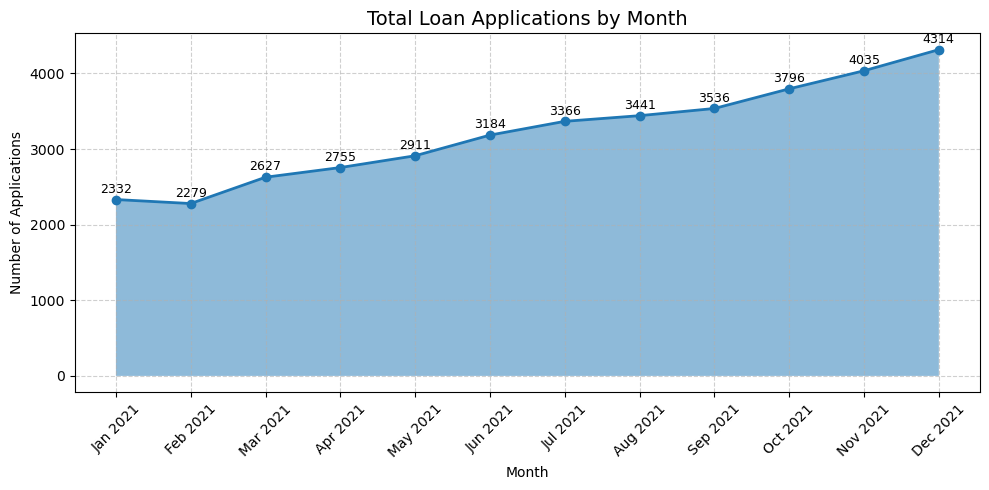

In [38]:
# Monthly Trends by Issue Date for Total Loan Applications

monthly_applications = (
    df.sort_values('issue_date')
      .assign(
          month_name=lambda x: x['issue_date'].dt.strftime('%b %Y')
      )
      .groupby('month_name', sort=False)['id']
      .count()
      .reset_index(name='loan_applications_count')
)

plt.figure(figsize=(10, 5))

plt.fill_between(
    range(len(monthly_applications)),
    monthly_applications['loan_applications_count'],
    alpha=0.5
)

plt.plot(
    range(len(monthly_applications)),
    monthly_applications['loan_applications_count'],
    linewidth=2,
    marker='o'
)

for i, row in monthly_applications.iterrows():
    plt.text(
        i,
        row['loan_applications_count'] + 50,
        f"{int(row['loan_applications_count'])}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Total Loan Applications by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')

plt.xticks(
    ticks=range(len(monthly_applications)),
    labels=monthly_applications['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Funded Amount

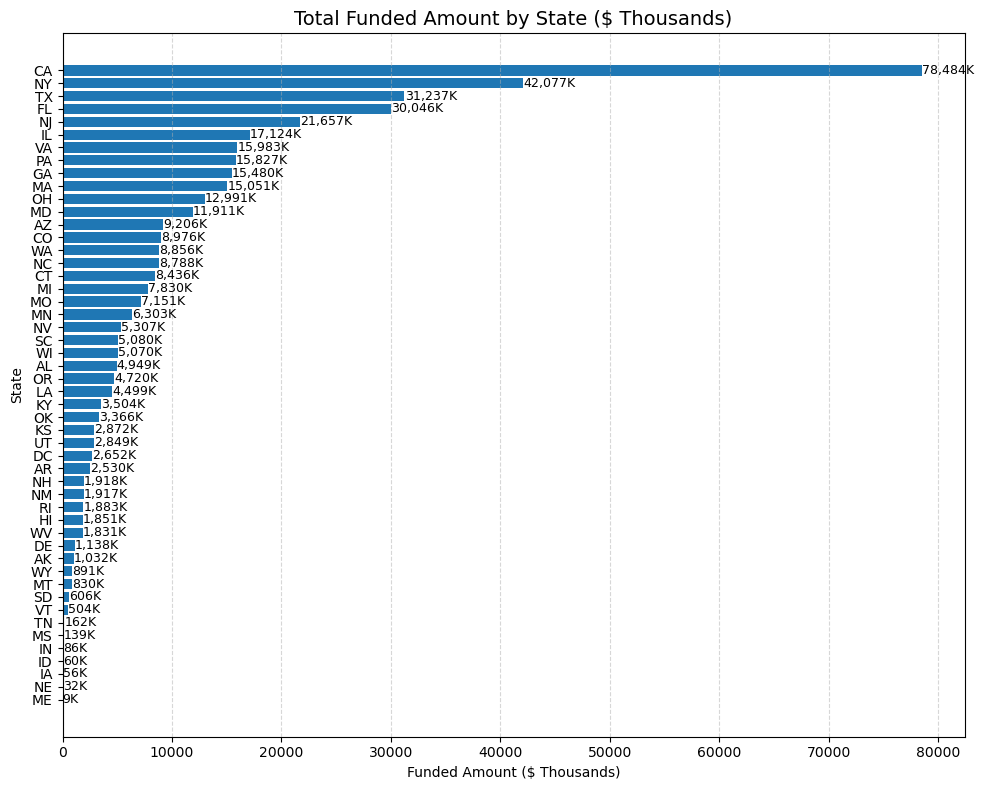

In [13]:
state_funding = (
    df.groupby('address_state')['loan_amount']
      .sum()
      .sort_values(ascending=True)
)

state_funding_thousands = state_funding / 1_000

plt.figure(figsize=(10, 8))

bars = plt.barh(
    state_funding_thousands.index,
    state_funding_thousands.values
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}K',
        va='center',
        fontsize=9
    )

plt.title('Total Funded Amount by State ($ Thousands)', fontsize=14)
plt.xlabel('Funded Amount ($ Thousands)')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Loan Term Analysis by Total Funded Amount

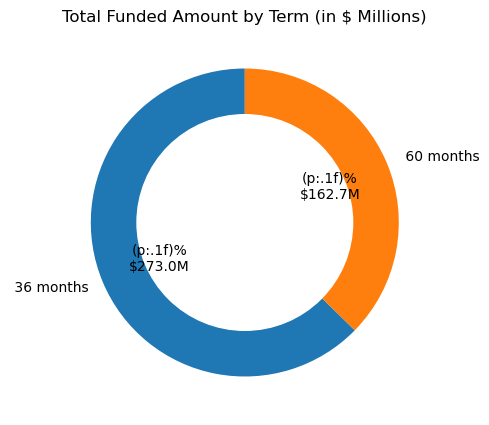

In [14]:
term_funding_millions = df. groupby ('term') ['loan_amount']. sum() / 1000000
plt.figure(figsize=(5, 5))
plt. pie(
term_funding_millions, labels=term_funding_millions.index,
autopct=lambda p: f"(p:.1f)%\n${p*sum(term_funding_millions)/100:.1f}M",
startangle=90, wedgeprops={'width': 0.4}
)
plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))
plt. title("Total Funded Amount by Term (in $ Millions)")
plt.show()

### Employee Length by Total Funded Amount

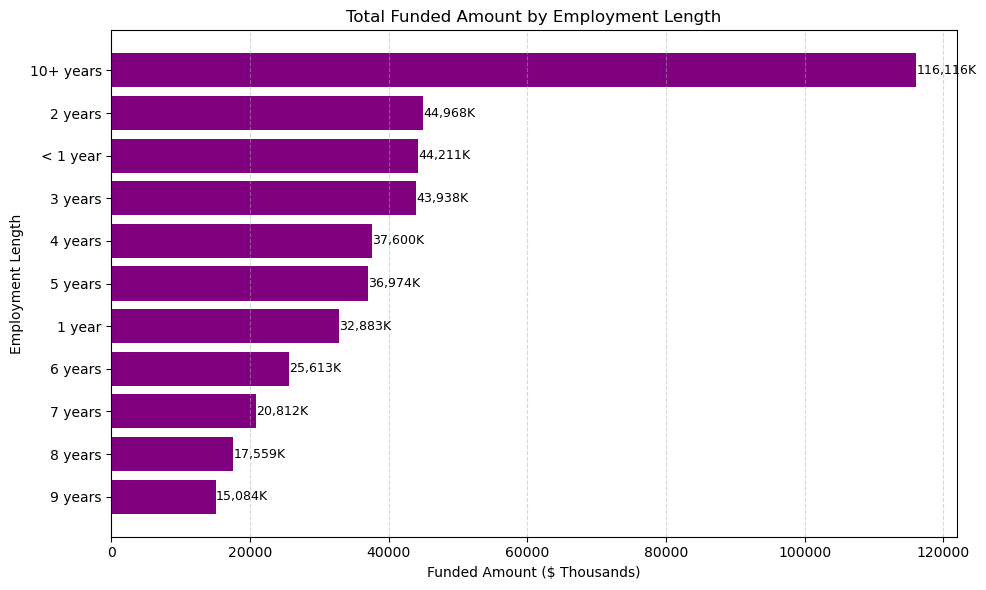

In [16]:
# Employee Length by Total Funded Amount

emp_funding = (
    df.groupby('emp_length')['loan_amount']
      .sum()
      .sort_values()
)

emp_funding_thousands = emp_funding / 1_000

plt.figure(figsize=(10, 6))

bars = plt.barh(
    emp_funding_thousands.index,
    emp_funding_thousands.values,
    color='purple'
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}K',
        va='center',
        fontsize=9
    )

plt.xlabel('Funded Amount ($ Thousands)')
plt.ylabel('Employment Length')
plt.title('Total Funded Amount by Employment Length')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Loan Purpose by Total Funded Amount

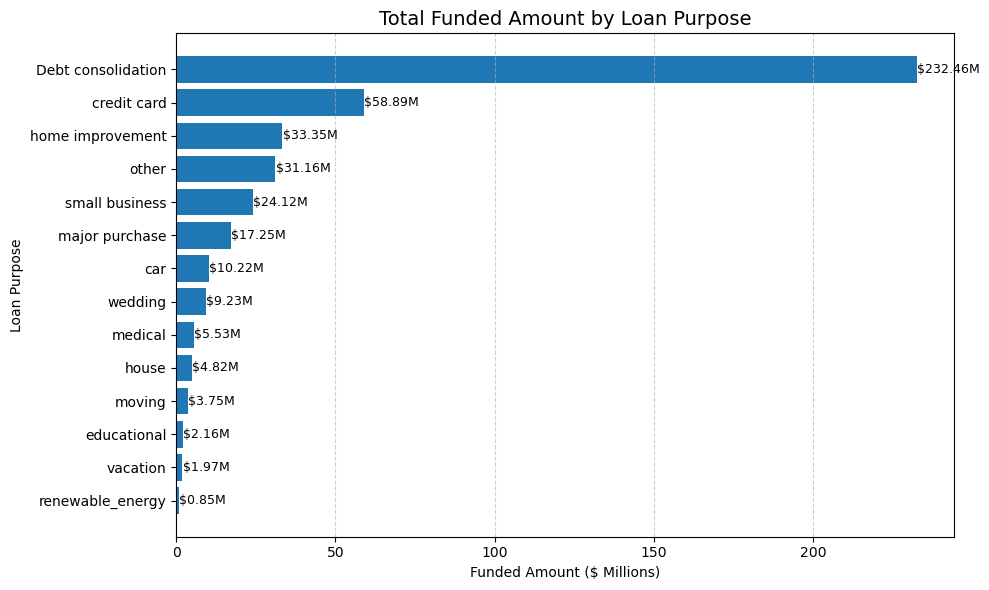

In [27]:
# Loan Purpose by Total Funded Amount

purpose_funding_millions = (
    df.groupby('purpose')['loan_amount']
      .sum()
      .sort_values()
      / 1_000_000
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    purpose_funding_millions.index,
    purpose_funding_millions.values
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'${width:.2f}M',
        va='center',
        fontsize=9
    )

plt.title('Total Funded Amount by Loan Purpose', fontsize=14)
plt.xlabel('Funded Amount ($ Millions)')
plt.ylabel('Loan Purpose')

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Home ownership by Total Funded Amount

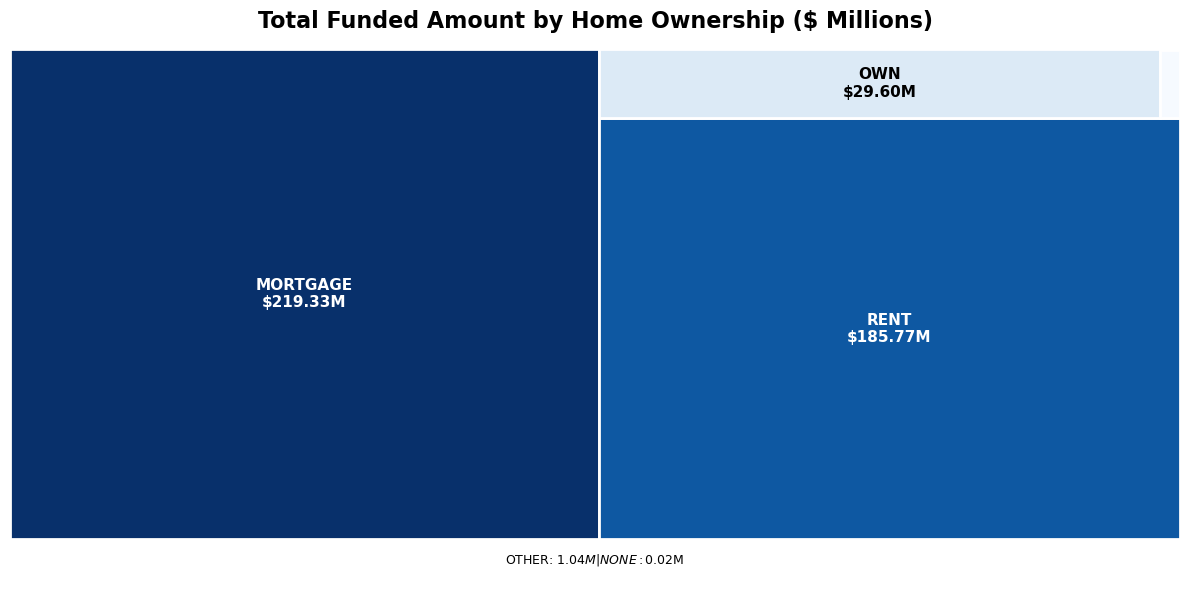

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.colors as colors
import squarify

# Prepare data
home_funding = (
    df.groupby('home_ownership')['loan_amount']
      .sum()
      .sort_values(ascending=False)
      / 1_000_000
)

# Create treemap rectangles
sizes = home_funding.values

norm_sizes = squarify.normalize_sizes(
    sizes,
    dx=100,
    dy=60
)

rects = squarify.squarify(
    norm_sizes,
    x=0,
    y=0,
    dx=100,
    dy=60
)

# Blue colour scale
norm = colors.Normalize(
    vmin=home_funding.min(),
    vmax=home_funding.max()
)

cmap = cm.Blues

# Create chart
fig, ax = plt.subplots(figsize=(12, 6))

for rect, (category, value) in zip(rects, home_funding.items()):

    colour = cmap(norm(value))

    ax.add_patch(
        patches.Rectangle(
            (rect["x"], rect["y"]),
            rect["dx"],
            rect["dy"],
            facecolor=colour,
            edgecolor="white",
            linewidth=2
        )
    )

    area = rect["dx"] * rect["dy"]

    # Large boxes: category + value
    if area > 150:
        label = f"{category}\n${value:.2f}M"
        fontsize = 11

    # Medium boxes: category only
    elif area > 20:
        label = category
        fontsize = 8

    # Very tiny boxes: don't squeeze text inside
    else:
        label = ""

    if label:
        # Dark boxes = white text, light boxes = black text
        text_colour = "white" if value > home_funding.max() * 0.35 else "black"

        ax.text(
            rect["x"] + rect["dx"] / 2,
            rect["y"] + rect["dy"] / 2,
            label,
            ha="center",
            va="center",
            fontsize=fontsize,
            fontweight="bold",
            color=text_colour
        )

# Mention tiny categories underneath
small_categories = home_funding[home_funding < 5]

small_text = "   |   ".join(
    [f"{name}: ${value:.2f}M" for name, value in small_categories.items()]
)

ax.text(
    50,
    -3,
    small_text,
    ha="center",
    fontsize=9
)

ax.set_xlim(0, 100)
ax.set_ylim(-5, 60)

ax.set_title(
    "Total Funded Amount by Home Ownership ($ Millions)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    "home_ownership_treemap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()